In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# Load dataset
file_path = '/Users/mahadfarah/Documents/Bellevue University/DSC 630 Predictive Analytics/Milestones/COVID-19 - Johns Hopkins University.csv'
df = pd.read_csv(file_path)

# Display
print(df.head())

# Display columns
print(df.columns)


       Country  Year  Daily new confirmed cases of COVID-19  \
0  Afghanistan    33                                    NaN   
1  Afghanistan    34                                    5.0   
2  Afghanistan    35                                    0.0   
3  Afghanistan    36                                    0.0   
4  Afghanistan    37                                    0.0   

   Daily new confirmed deaths due to COVID-19  \
0                                         NaN   
1                                         NaN   
2                                         NaN   
3                                         NaN   
4                                         NaN   

   Total confirmed cases of COVID-19  Total confirmed deaths due to COVID-19  \
0                                NaN                                     NaN   
1                                5.0                                     NaN   
2                                5.0                                     NaN   
3     

In [33]:
# Clean column names and strip spaces
df.columns = df.columns.str.strip()

# Check columns names again
print(df.columns.tolist())

# Update column name
df['daily_new_cases_rolling_avg'] = df['Daily new confirmed cases due to COVID-19 (rolling 7-day average, right-aligned)']  # Adjust the column name accordingly


['Country', 'Year', 'Daily new confirmed cases of COVID-19', 'Daily new confirmed deaths due to COVID-19', 'Total confirmed cases of COVID-19', 'Total confirmed deaths due to COVID-19', 'Daily new confirmed cases of COVID-19 per million people', 'Daily new confirmed deaths due to COVID-19 per million people', 'Total confirmed cases of COVID-19 per million people', 'Total confirmed deaths due to COVID-19 per million people', 'Days since the total confirmed cases of COVID-19 reached 100', 'Days since the total confirmed deaths of COVID-19 reached 5', 'Days since the total confirmed cases of COVID-19 per million people reached 1', 'Days since the total confirmed deaths of COVID-19 per million people reached 0.1', 'Daily new confirmed cases due to COVID-19 (rolling 7-day average, right-aligned)', 'Daily new confirmed deaths due to COVID-19 (rolling 7-day average, right-aligned)', 'Daily new confirmed cases of COVID-19 per million people (rolling 7-day average, right-aligned)', 'Daily new c

In [34]:
# Convert date column to datetime format (assuming there is a date column, adjust if necessary)
# df['date'] = pd.to_datetime(df['date'])  # Uncomment if date column is present

# Create binary target: Surge = 1 if 30% increase in 7-day rolling average new cases
df['daily_new_cases_rolling_avg'] = df['daily_new_cases_rolling_avg']
df['surge'] = (df['daily_new_cases_rolling_avg'] / df['daily_new_cases_rolling_avg'].shift(7) > 1.3).astype(int)

# Lag features: using previous data to predict future surges
df['weekly_cases_lag'] = df['Weekly cases'].shift(7)
df['weekly_case_growth_lag'] = df['Weekly case growth (%)'].shift(7)
df['fatality_rate_lag'] = df['Case fatality rate of COVID-19 (%)'].shift(7)

# Drop missing values (rows)
df.dropna(subset=['surge'], inplace=True)

# Select relevant features and target
features = ['daily_new_cases_rolling_avg', 'weekly_cases_lag', 'weekly_case_growth_lag', 'fatality_rate_lag']
target = 'surge'

# Extract data for model training
df_country = df[df['Country'] == 'United States']

# Split into features and target
X = df_country[features]
y = df_country[target]

# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


In [35]:
# Combine X and y into a one dataframe
df_combined = pd.DataFrame(X, columns=features)
df_combined['target'] = y

# Drop rows with missing values from all columns
df_combined_clean = df_combined.dropna()

# Split back into X and y
X_clean = df_combined_clean[features]
y_clean = df_combined_clean['target']

# Train-test split
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(X_clean, y_clean, test_size=0.3, random_state=42)

# Print shapes
print(f"Shape of X_train_clean: {X_train_clean.shape}")
print(f"Shape of y_train_clean: {y_train_clean.shape}")


Shape of X_train_clean: (769, 4)
Shape of y_train_clean: (769,)


In [36]:
# Logistic Regression model
log_reg = LogisticRegression(random_state=42)

# Fit model with cleaned train data
log_reg.fit(X_train_clean, y_train_clean)

# Predict/evaluate
y_pred_log_reg = log_reg.predict(X_test_clean)
accuracy_log_reg = accuracy_score(y_test_clean, y_pred_log_reg)
precision_log_reg = precision_score(y_test_clean, y_pred_log_reg)
recall_log_reg = recall_score(y_test_clean, y_pred_log_reg)
f1_log_reg = f1_score(y_test_clean, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test_clean, y_pred_log_reg)

# Print evaluation metrics
print("Logistic Regression Metrics:")
print(f"Accuracy: {accuracy_log_reg:.2f}")
print(f"Precision: {precision_log_reg:.2f}")
print(f"Recall: {recall_log_reg:.2f}")
print(f"F1 Score: {f1_log_reg:.2f}")
print("Confusion Matrix:\n", conf_matrix_log_reg)


Logistic Regression Metrics:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
Confusion Matrix:
 [[293   0]
 [  0  37]]


In [37]:
# XGBoost Classifier
xgb = XGBClassifier(random_state=42, scale_pos_weight=1)
xgb.fit(X_train, y_train)

# Predict/evaluate
y_pred_xgb = xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

# Print evaluation metrics
print("XGBoost Metrics:")
print(f"Accuracy: {accuracy_xgb:.2f}")
print(f"Precision: {precision_xgb:.2f}")
print(f"Recall: {recall_xgb:.2f}")
print(f"F1 Score: {f1_xgb:.2f}")
print("Confusion Matrix:\n", conf_matrix_xgb)


XGBoost Metrics:
Accuracy: 0.98
Precision: 0.98
Recall: 0.86
F1 Score: 0.92
Confusion Matrix:
 [[291   1]
 [  7  44]]


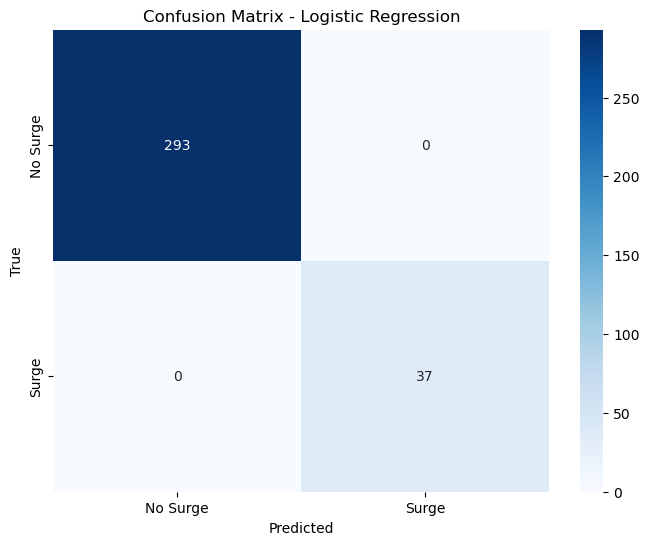

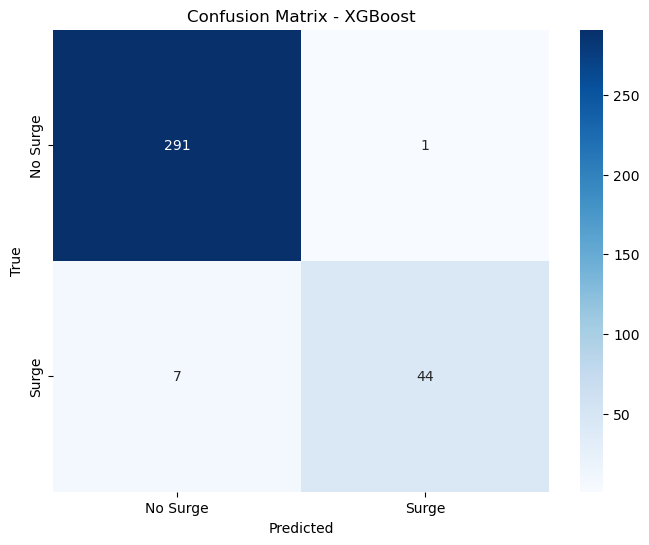

In [38]:
import seaborn as sns

# Confusion Matrix for Logistic Regression
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues', xticklabels=['No Surge', 'Surge'], yticklabels=['No Surge', 'Surge'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Confusion Matrix for XGBoost
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['No Surge', 'Surge'], yticklabels=['No Surge', 'Surge'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


<Figure size 1000x600 with 0 Axes>

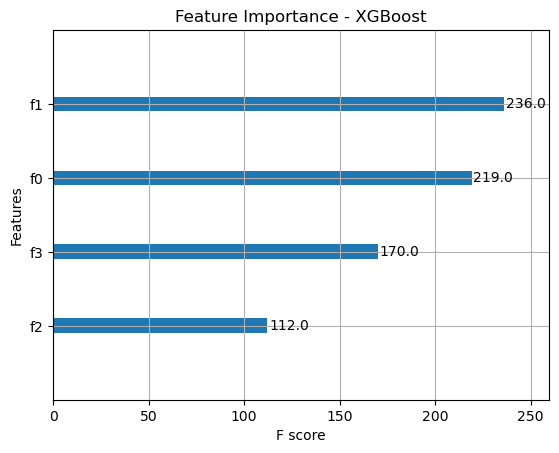

In [41]:
import xgboost as xgb
import matplotlib.pyplot as plt

# Train XGBoost model
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# Booster object
booster = xgb_model.get_booster()

# Plot feaature importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(booster, importance_type='weight', max_num_features=10)
plt.title('Feature Importance - XGBoost')
plt.show()


In [42]:
# Check class distribution
print("Class distribution in y_train:")
print(y_train.value_counts())


Class distribution in y_train:
0    693
1    107
Name: surge, dtype: int64


In [43]:
from sklearn.model_selection import cross_val_score

# Cross-validation on logistic regression
cv_scores = cross_val_score(log_reg, X_clean, y_clean, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Average cross-validation score: {cv_scores.mean()}")


Cross-validation scores: [1.         0.99090909 1.         1.         0.99543379]
Average cross-validation score: 0.9972685761726858
